In [1]:
from simulator import Config, Simulator

config = Config()
config.NODE_POWER_W = 0.2  # Node power consumption in W
simulator = Simulator(config)

# CSV including time series data for production (G(h) in kWh, and Temperature in °C)
production_data = "raw-data/CR.csv"

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from visualization import (
    get_config_trace,
    plot_soc,
    plot_soc_gh,
    plot_soc_ibatt,
    plot_daily,
    plot_seasonal_soc,
    plot_full_soc_analysis,
    plot_pareto_front,
)


## Run Complete Simulation

This single function call executes the entire pipeline:
1. Load irradiance data
2. Compute PV power for all panel sizes
3. Compute hourly power balance with PMU efficiency
4. Simulate battery State of Charge for all configurations
5. Evaluate viability and compute scores

In [3]:
# Run the full simulation
results = simulator.run_full_simulation(production_data)

# Extract results
df_pv = results['df_pv']
df_pv_pmu = results['df_pv_pmu']
df_soc = results['df_soc']
summary = results['summary']

Loading irradiance data...
Computing PV power...
Computing hourly balance...
Simulating battery SoC...
Evaluating viability...
Computing optimal scores...
Done!


## Design space

In [4]:
df_design = simulator.build_design_space()
df_design

,panel_area_m2,battery_capacity_Ah,eta_PMU
0,0.0001,0.105,0.87
1,0.0001,0.105,0.90
2,0.0001,0.105,0.95
3,0.0001,0.105,0.98
4,0.0001,0.350,0.87
...,...,...,...
667,0.0400,3.200,0.98
668,0.0400,2.300,0.87
669,0.0400,2.300,0.90
670,0.0400,2.300,0.95


## Explore Results

In [5]:
print("Top 10 configurations by score:")
summary.head(10)

Top 10 configurations by score:


,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
0,0.031,2.3,0.98,8760,0,3058,0.883951,0.121653,255.096030,1909.549342,8760,0,46.0,1.226610,0.0,0.349087,-1654.453312,0.201937
1,0.031,2.5,0.95,8760,0,2959,0.887094,0.118404,263.496779,1788.238745,8760,0,1.5,1.151089,0.0,0.337785,-1524.741966,0.188107
2,0.040,1.6,0.95,8760,0,3225,0.837927,0.171649,260.905214,2366.623621,8760,0,4.8,1.500184,0.0,0.368151,-2105.718406,0.187095
3,0.025,3.2,0.95,8760,0,2708,0.903692,0.102244,266.177723,1403.509121,8760,0,9.6,0.918358,0.0,0.309132,-1137.331398,0.184044
4,0.040,1.6,0.98,8760,0,3281,0.845703,0.165137,252.647842,2525.178271,8760,0,4.8,1.598102,0.0,0.374543,-2272.530429,0.182046
5,0.031,2.5,0.98,8760,0,3058,0.893235,0.111921,255.096030,1909.549342,8760,0,1.5,1.226610,0.0,0.349087,-1654.453312,0.179181
6,0.025,3.2,0.98,8760,0,2795,0.909525,0.095789,257.624558,1499.990962,8760,0,9.6,0.978949,0.0,0.319064,-1242.366403,0.176201
7,0.040,2.0,0.95,8760,0,3225,0.870342,0.137320,260.905214,2366.623621,8760,0,2.0,1.500184,0.0,0.368151,-2105.718406,0.141583
8,0.040,2.0,0.98,8760,0,3281,0.876563,0.132110,252.647842,2525.178271,8760,0,2.0,1.598102,0.0,0.374543,-2272.530429,0.136535
9,0.031,3.2,0.90,8760,0,2821,0.902512,0.102448,278.805784,1594.927364,8760,0,9.6,1.030550,0.0,0.322032,-1316.121580,0.120903


## Best combinations

In [6]:
best_configs = summary[summary["score"] == summary["score"].max()]

for config_idx, config_row in best_configs.iterrows():
    print()
    print(config_row[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])


panel_area_m2    0.031000
C_batt_Ah        2.300000
eta_PMU          0.980000
score            0.201937
Name: 0, dtype: float64


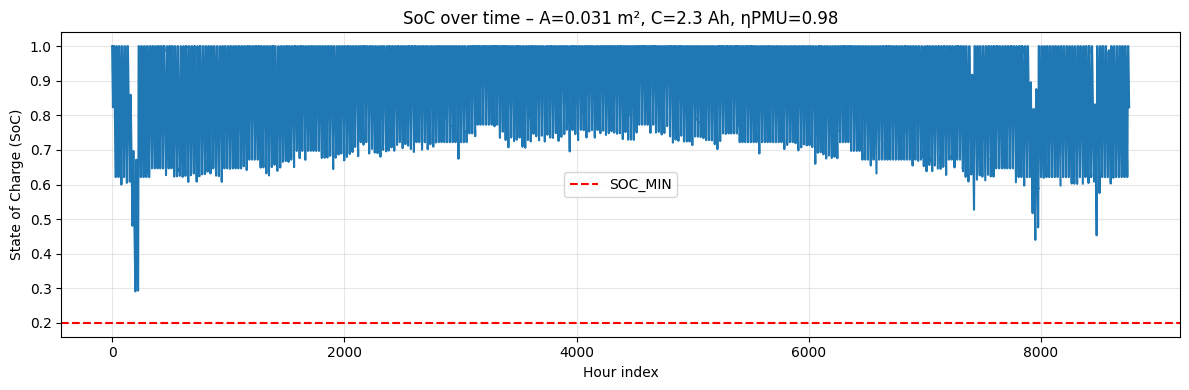

In [7]:
for _, cfg in best_configs.iterrows():
    config_soc = df_soc[
        (df_soc['panel_area_m2'] == cfg['panel_area_m2']) &
        (df_soc['C_batt_Ah'] == cfg['C_batt_Ah']) &
        (df_soc['eta_PMU'] == cfg['eta_PMU'])
    ].copy()

    plt.figure(figsize=(12, 4))
    plt.plot(config_soc['hour_index'], config_soc['SoC'])
    plt.axhline(y=Config.SOC_MIN, color='r', linestyle='--', label='SOC_MIN')
    plt.xlabel('Hour index')
    plt.ylabel('State of Charge (SoC)')
    plt.title(
        f"SoC over time – A={cfg['panel_area_m2']} m², "
        f"C={cfg['C_batt_Ah']} Ah, ηPMU={cfg['eta_PMU']}"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Plot best configurations

Visualize all configurations in 3D space (panel area × battery capacity × PMU efficiency)

In [8]:
LOG_COLOR = False

data = summary.copy()

if LOG_COLOR:
    eps = 1e-9
    data["score_color"] = np.log10(data["score"] + eps)
    color_label = "log10(score)"
else:
    data["score_color"] = data["score"]
    color_label = "score"

fig = px.scatter_3d(
    data,
    x="panel_area_m2",
    y="C_batt_Ah",
    z="eta_PMU",
    color="score_color",
    labels={
        "panel_area_m2": "Panel area (m²)",
        "C_batt_Ah": "Battery (Ah)",
        "eta_PMU": "PMU efficiency",
        "score_color": color_label
    },
    opacity=0.85
)

fig.update_layout(
    width=1000,
    height=800,
    title=f"All configurations ({'log color scale' if LOG_COLOR else 'linear color scale'})"
)

fig.show()

## Score Distribution Histogram

In [9]:
fig = px.histogram(
    summary,
    x="score",
    nbins=50,
    labels={"score": "score"},
    opacity=0.85,
)

fig.update_layout(
    width=900,
    height=500,
    title="Score distribution",
    bargap=0.05
)

fig.show()

## Score at Maximum PMU Efficiency (not best configs)

In [10]:
eta_max = summary["eta_PMU"].max()
df_plane = summary[summary["eta_PMU"] == eta_max].copy()

df_pivot = (
    df_plane
    .pivot_table(
        index="C_batt_Ah",
        columns="panel_area_m2",
        values="score",
        aggfunc="mean"
    )
    .sort_index()
    .sort_index(axis=1)
)

X = df_pivot.columns.values
Y = df_pivot.index.values
X_grid, Y_grid = np.meshgrid(X, Y)
Z = df_pivot.values

fig = go.Figure(
    data=[
        go.Surface(
            x=X_grid,
            y=Y_grid,
            z=Z,
            colorscale="Viridis",
            colorbar={"title": "Score"}
        )
    ]
)

fig.update_layout(
    title=f"Score surface for max η_PMU ({eta_max})",
    scene=dict(
        xaxis_title="Panel area (m²)",
        yaxis_title="Battery capacity (Ah)",
        zaxis_title="Score"
    ),
    width=900,
    height=700
)

fig.show()

## Summary statistics

In [11]:
print("\n=== Simulation Summary ===")
print(f"Total configurations evaluated: {len(summary)}")
print(f"Best score achieved: {summary['score'].max():.4f}")
print(f"Configurations with best score: {len(summary[summary['score'] == summary['score'].max()])}")
print(f"Configurations with failures: {len(summary[summary['failure_hours'] > 0])}")
print("Configuration with I_req_max > I_batt_max):",
      len(summary[summary["I_req_max_A"] > summary["I_batt_max_A"]]))



=== Simulation Summary ===
Total configurations evaluated: 672
Best score achieved: 0.2019
Configurations with best score: 1
Configurations with failures: 649
Configuration with I_req_max > I_batt_max): 110


## Invalidad configs due to < SoC_min

In [12]:
invalid_soc = summary[summary["failure_hours"] > 0][[
    "panel_area_m2",
    "C_batt_Ah",
    "eta_PMU",
    "failure_hours",
    "autonomy_hours",
    "I_batt_max_A",
    "I_req_max_A"
]].sort_values("failure_hours", ascending=False)

invalid_soc


,panel_area_m2,C_batt_Ah,eta_PMU,failure_hours,autonomy_hours,I_batt_max_A,I_req_max_A
375,0.000400,0.120,0.95,8758,2,0.2400,0.056899
376,0.000400,0.120,0.98,8758,2,0.2400,0.055157
370,0.000400,0.105,0.90,8758,2,0.1575,0.060060
369,0.000400,0.105,0.87,8758,2,0.1575,0.062131
378,0.000625,0.105,0.98,8758,2,0.1575,0.055157
...,...,...,...,...,...,...,...
196,0.031000,2.000,0.98,3,8558,2.0000,1.226610
241,0.031000,3.200,0.87,3,8535,9.6000,0.961424
234,0.040000,2.000,0.90,2,8559,2.0000,1.343865
235,0.040000,2.300,0.87,1,8536,46.0000,1.254200


## Invalid configs due I_req > I_batt_max

In [13]:
invalid_peak = summary[
    summary["I_req_max_A"] > summary["I_batt_max_A"]
][[
    "panel_area_m2",
    "C_batt_Ah",
    "eta_PMU",
    "I_req_max_A",
    "I_batt_max_A",
    "failure_hours",
    "autonomy_hours"
]].sort_values("I_req_max_A", ascending=False)

invalid_peak


,panel_area_m2,C_batt_Ah,eta_PMU,I_req_max_A,I_batt_max_A,failure_hours,autonomy_hours
18,0.04000,2.500,0.98,1.598102,1.5000,0,8760
245,0.04000,0.105,0.98,1.598102,0.1575,4244,16
230,0.04000,1.200,0.98,1.598102,1.2000,4,8278
236,0.04000,0.500,0.98,1.598102,0.5000,2339,21
218,0.04000,0.400,0.98,1.598102,0.6000,2770,20
...,...,...,...,...,...,...,...
169,0.00800,0.105,0.90,0.229854,0.1575,4980,16
178,0.00800,0.105,0.87,0.213218,0.1575,5041,16
122,0.00625,0.105,0.98,0.205007,0.1575,5095,16
121,0.00625,0.105,0.95,0.191076,0.1575,5137,16


In [14]:
summary["autonomy_hours"].describe()


count     672.000000
mean     1385.197917
std      2706.418552
min         2.000000
25%        16.000000
50%        21.000000
75%       163.750000
max      8760.000000
Name: autonomy_hours, dtype: float64

In [15]:
summary.sort_values("autonomy_hours").head(5)


,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
382,0.000625,0.12,0.98,8760,8758,1,0.200127,0.009190,438.492247,-0.0,2,8758,0.24,0.055157,0.999772,0.000114,438.492247,0.0
608,0.001000,0.12,0.95,8760,8758,1,0.200126,0.009132,426.939585,-0.0,2,8758,0.24,0.056899,0.999772,0.000114,426.939585,0.0
381,0.000625,0.12,0.95,8760,8758,1,0.200126,0.009132,453.750470,-0.0,2,8758,0.24,0.056899,0.999772,0.000114,453.750470,0.0
595,0.001000,0.12,0.87,8760,8758,1,0.200120,0.008971,472.772714,-0.0,2,8758,0.24,0.062131,0.999772,0.000114,472.772714,0.0
596,0.001000,0.12,0.90,8760,8758,1,0.200123,0.009032,454.630434,-0.0,2,8758,0.24,0.060060,0.999772,0.000114,454.630434,0.0


In [16]:
summary.sort_values("autonomy_hours").tail(5)

,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
19,0.040,3.2,0.87,8760,0,3023,0.905439,0.098671,285.786515,1968.958645,8760,0,9.6,1.254200,0.0,0.345091,-1683.172130,0.023260
14,0.040,2.3,0.98,8760,0,3281,0.892663,0.114878,252.647842,2525.178271,8760,0,46.0,1.598102,0.0,0.374543,-2272.530429,0.102401
13,0.040,2.5,0.87,8760,0,3023,0.878962,0.126300,285.786515,1968.958645,8760,0,1.5,1.254200,0.0,0.345091,-1683.172130,0.102905
11,0.031,3.2,0.95,8760,0,2959,0.911792,0.092503,263.496779,1788.238745,8760,0,9.6,1.151089,0.0,0.337785,-1524.741966,0.108461
0,0.031,2.3,0.98,8760,0,3058,0.883951,0.121653,255.096030,1909.549342,8760,0,46.0,1.226610,0.0,0.349087,-1654.453312,0.201937


In [17]:
# 1) Maximum score configuration
cfg_best = summary.sort_values("score", ascending=False).iloc[0]

# 2) Minimum non-zero score configuration
summary_nonzero = summary[summary["score"] > 0]
cfg_bad = summary_nonzero.sort_values("score", ascending=True).iloc[0]

# 3) Score closest to 0.5 (mid-score representative)
target = 0.5
idx_mid = (summary["score"] - target).abs().idxmin()
cfg_mid = summary.loc[idx_mid]

# 4) Failure case (for comparison)
cfg_fail = summary[summary["score"] == 0].sort_values("score").iloc[0]


print("\n=== BEST SCORE CONFIGURATION ===")
print(cfg_best[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== BAD NON-ZERO SCORE CONFIGURATION ===")
print(cfg_bad[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== MID-SCORE (~0.5) CONFIGURATION ===")
print(cfg_mid[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== FAILURE CASE CONFIGURATION ===")
print(cfg_fail[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])



=== BEST SCORE CONFIGURATION ===
panel_area_m2    0.031000
C_batt_Ah        2.300000
eta_PMU          0.980000
score            0.201937
Name: 0, dtype: float64

=== BAD NON-ZERO SCORE CONFIGURATION ===
panel_area_m2    0.040000
C_batt_Ah        3.200000
eta_PMU          0.950000
score            0.005049
Name: 21, dtype: float64

=== MID-SCORE (~0.5) CONFIGURATION ===
panel_area_m2    0.031000
C_batt_Ah        2.300000
eta_PMU          0.980000
score            0.201937
Name: 0, dtype: float64

=== FAILURE CASE CONFIGURATION ===
panel_area_m2    0.010
C_batt_Ah        0.105
eta_PMU          0.900
score            0.000
Name: 22, dtype: float64


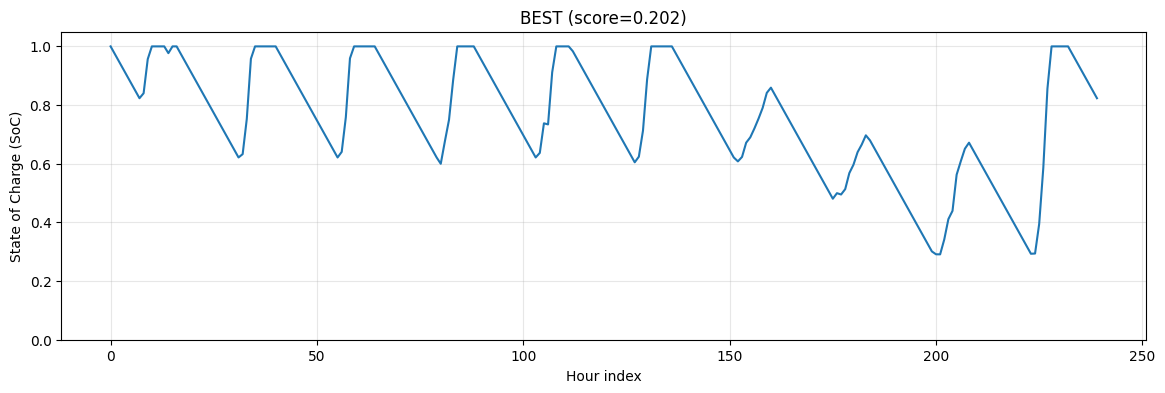

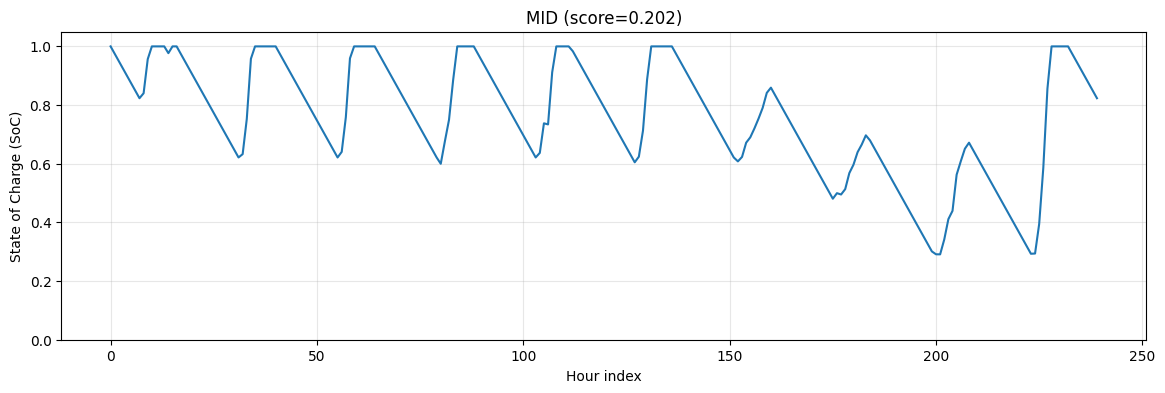

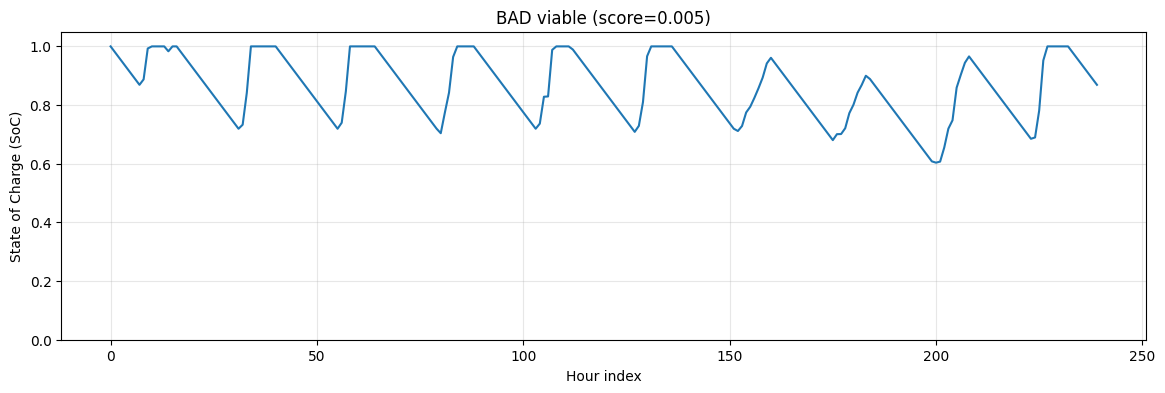

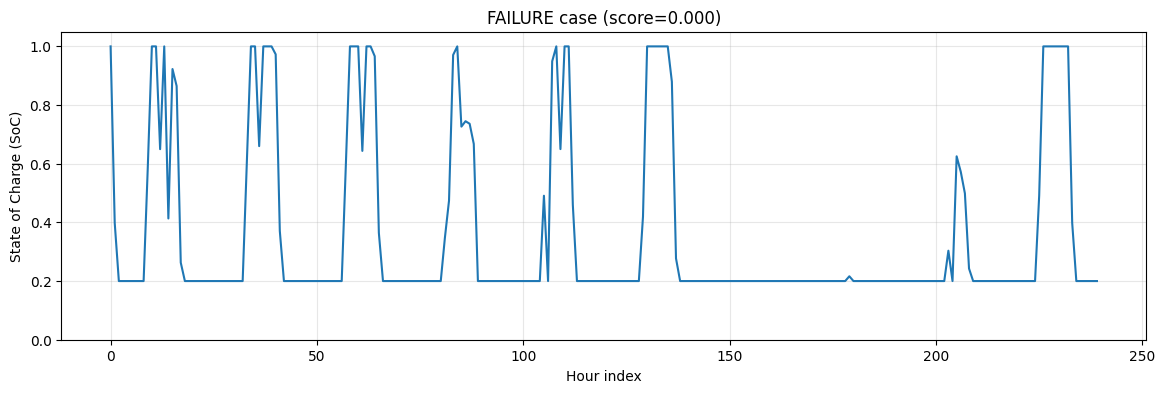

In [18]:
# BEST SCORE
plot_soc(
    df_soc,
    cfg_best["panel_area_m2"],
    cfg_best["C_batt_Ah"],
    cfg_best["eta_PMU"],
    title=f"BEST (score={cfg_best['score']:.3f})"
)

# MID SCORE (~0.5)
plot_soc(
    df_soc,
    cfg_mid["panel_area_m2"],
    cfg_mid["C_batt_Ah"],
    cfg_mid["eta_PMU"],
    title=f"MID (score={cfg_mid['score']:.3f})"
)

# BAD NON-ZERO SCORE
plot_soc(
    df_soc,
    cfg_bad["panel_area_m2"],
    cfg_bad["C_batt_Ah"],
    cfg_bad["eta_PMU"],
    title=f"BAD viable (score={cfg_bad['score']:.3f})"
)

# FAILURE CASE
plot_soc(
    df_soc,
    cfg_fail["panel_area_m2"],
    cfg_fail["C_batt_Ah"],
    cfg_fail["eta_PMU"],
    title=f"FAILURE case (score={cfg_fail['score']:.3f})"
)

In [19]:
from visualization import (
    get_config_trace,
    plot_soc_gh,
    plot_soc_ibatt,
    plot_daily,
    plot_seasonal_soc
)


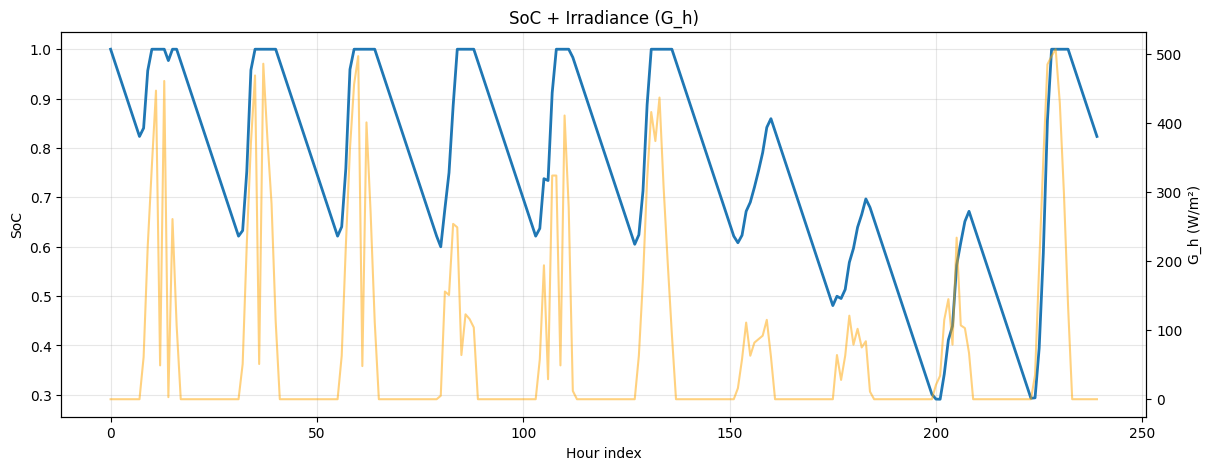

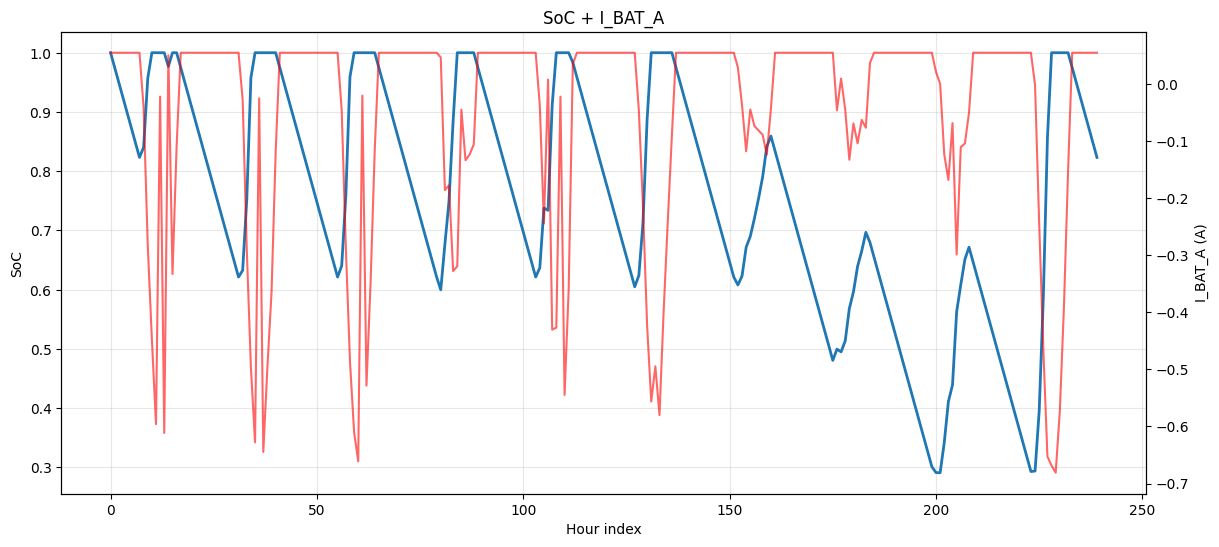

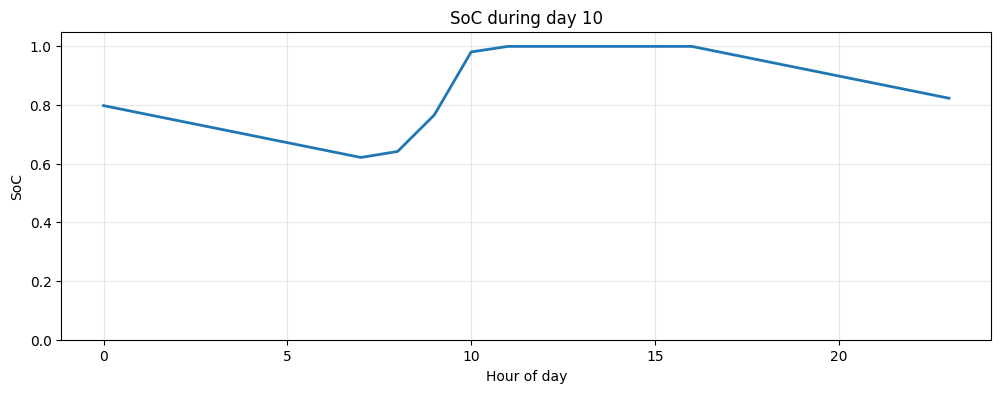

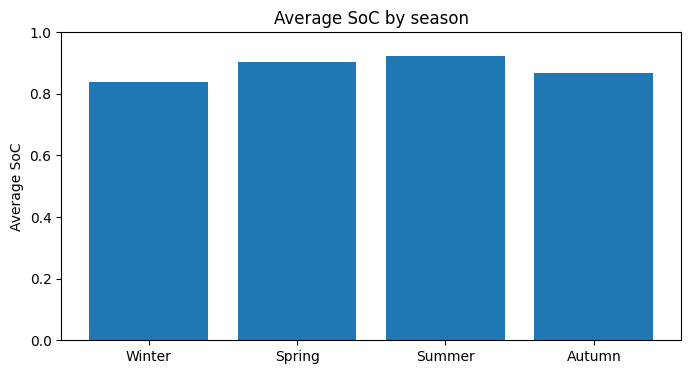

In [20]:
# Choose a configuration, e.g. cfg_mid (score ~0.5)
panel  = cfg_mid["panel_area_m2"]
cap    = cfg_mid["C_batt_Ah"]
eta    = cfg_mid["eta_PMU"]

cfg = get_config_trace(df_soc, panel, cap, eta)

plot_soc_gh(cfg, df_pv, hours=240, title="SoC + Irradiance (G_h)")
plot_soc_ibatt(cfg, hours=240, title="SoC + I_BAT_A")
plot_daily(cfg, day_index=10)
plot_seasonal_soc(cfg)


In [21]:
# Sort all configurations by score
summary_sorted = summary.sort_values("score", ascending=False)

# 1) Best score
cfg_best = summary_sorted.iloc[0]
title_best = f"BEST - Panel: {cfg_best['panel_area_m2']} m², Batería: {cfg_best['C_batt_Ah']} Ah, PMU: {cfg_best['eta_PMU']}, Score: {cfg_best['score']:.3f}"

# 2) BAD non-zero score
cfg_bad = summary_sorted[summary_sorted["score"] > 0].sort_values("score").iloc[0]
title_bad = f"BAD - Panel: {cfg_bad['panel_area_m2']} m², Batería: {cfg_bad['C_batt_Ah']} Ah, PMU: {cfg_bad['eta_PMU']}, Score: {cfg_bad['score']:.3f}"

# 3) MID score (between BAD and BEST)
configs_between = summary_sorted[
    (summary_sorted["score"] > cfg_bad["score"]) &
    (summary_sorted["score"] < cfg_best["score"])
].sort_values("score")
cfg_mid = configs_between.iloc[len(configs_between) // 2]
title_mid = f"MID - Panel: {cfg_mid['panel_area_m2']} m², Batería: {cfg_mid['C_batt_Ah']} Ah, PMU: {cfg_mid['eta_PMU']}, Score: {cfg_mid['score']:.3f}"

# 4) Failure case (for comparison)
cfg_fail = summary_sorted[summary_sorted["score"] == 0].sort_values("score").iloc[0]
title_fail = f"FAIL - Panel: {cfg_fail['panel_area_m2']} m², Batería: {cfg_fail['C_batt_Ah']} Ah, PMU: {cfg_fail['eta_PMU']}, Score: {cfg_fail['score']:.3f}"

print("\nBEST:", cfg_best[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nMID:", cfg_mid[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nBAD:", cfg_bad[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nFAIL:", cfg_fail[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])



BEST: panel_area_m2    0.031000
C_batt_Ah        2.300000
eta_PMU          0.980000
score            0.201937
Name: 0, dtype: float64

MID: panel_area_m2    0.040000
C_batt_Ah        2.300000
eta_PMU          0.900000
score            0.117727
Name: 10, dtype: float64

BAD: panel_area_m2    0.040000
C_batt_Ah        3.200000
eta_PMU          0.950000
score            0.005049
Name: 21, dtype: float64

FAIL: panel_area_m2    0.010
C_batt_Ah        0.105
eta_PMU          0.900
score            0.000
Name: 22, dtype: float64


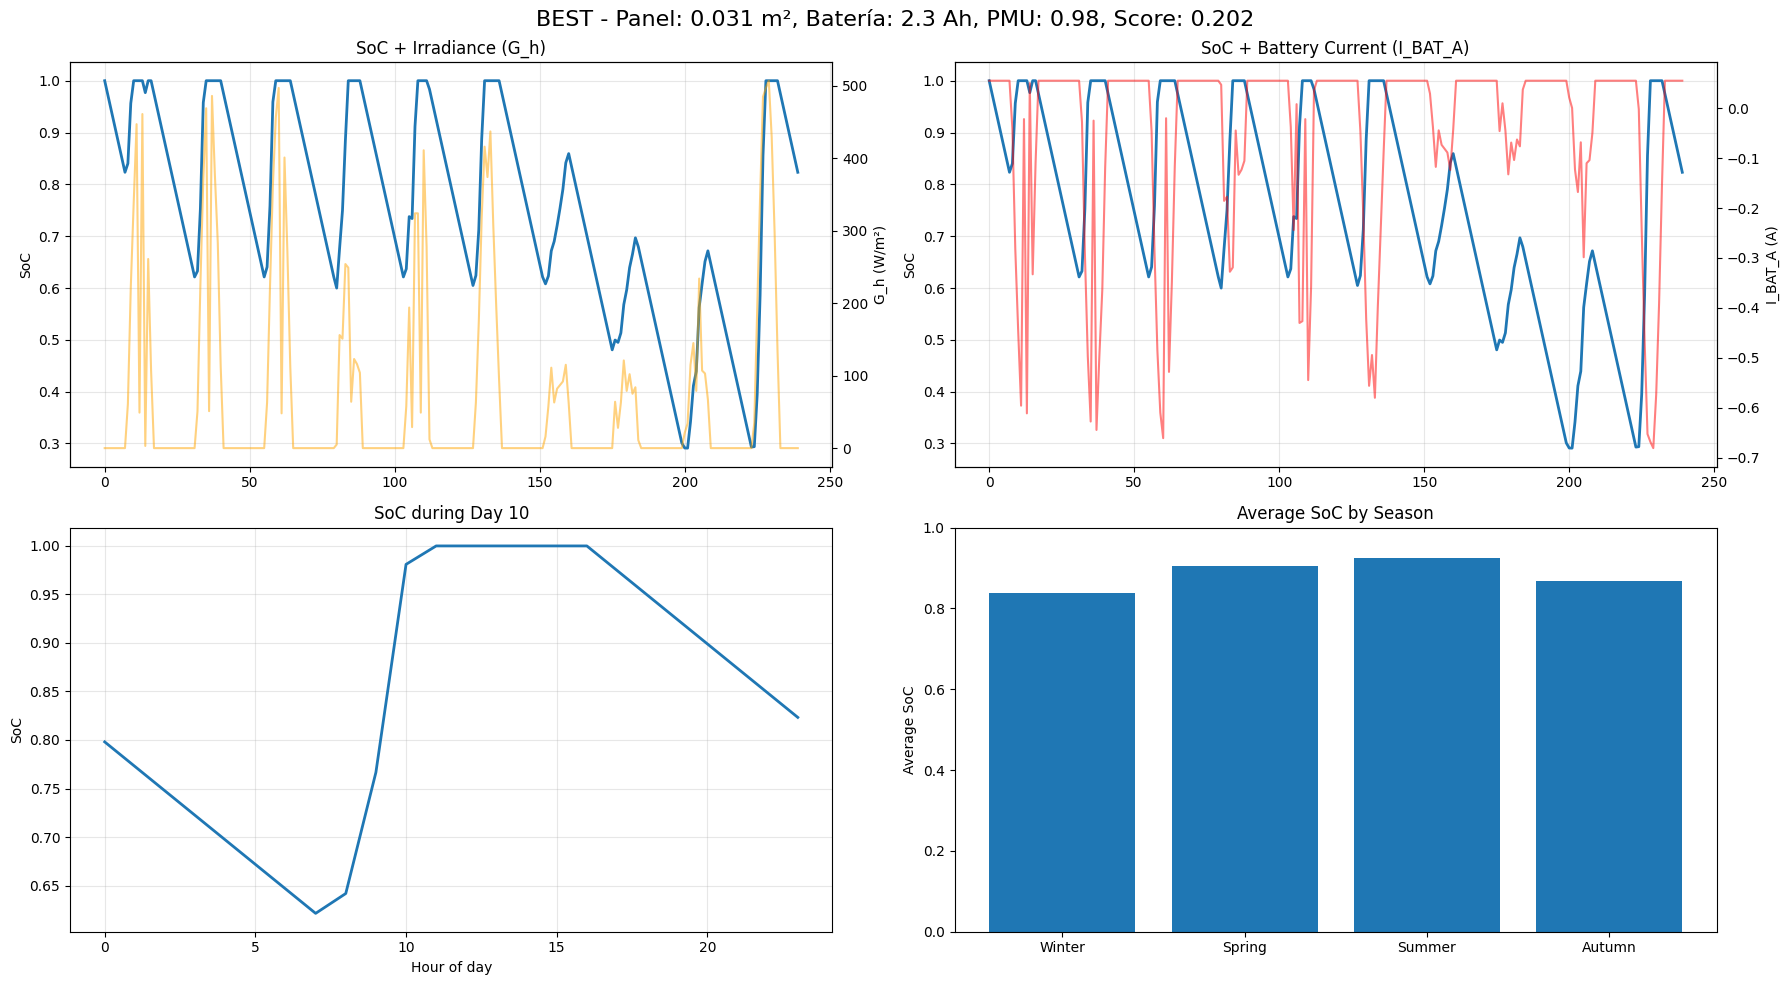

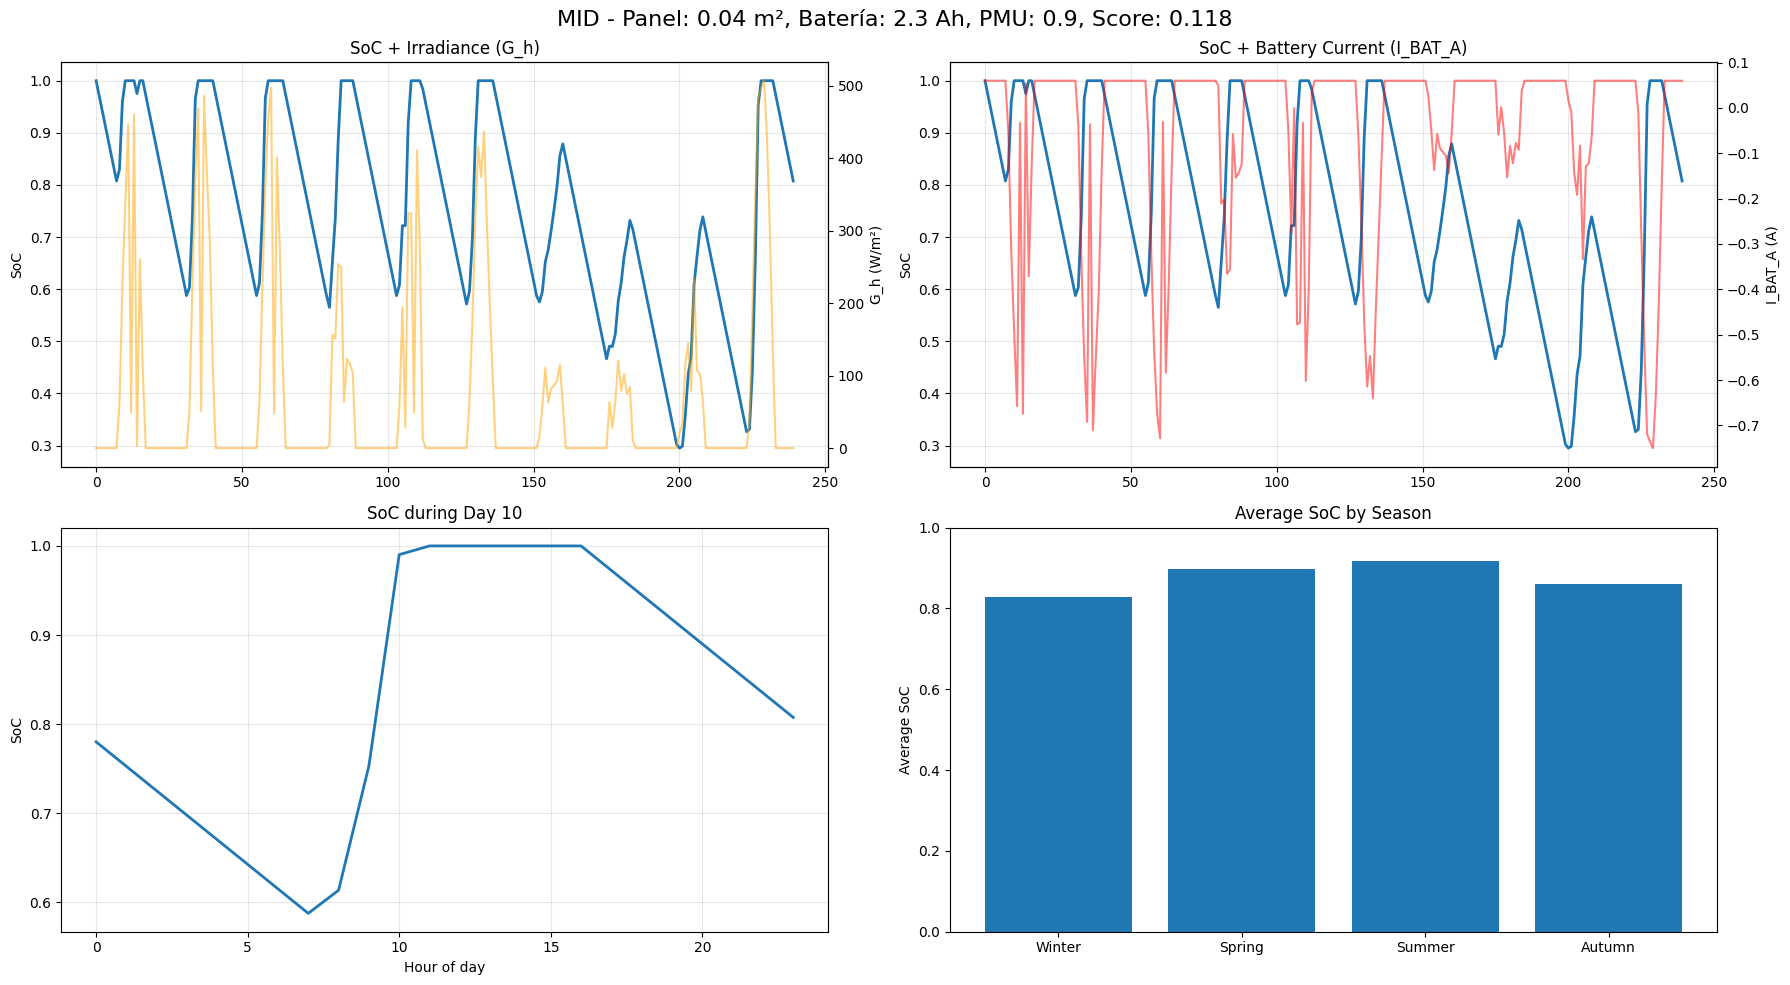

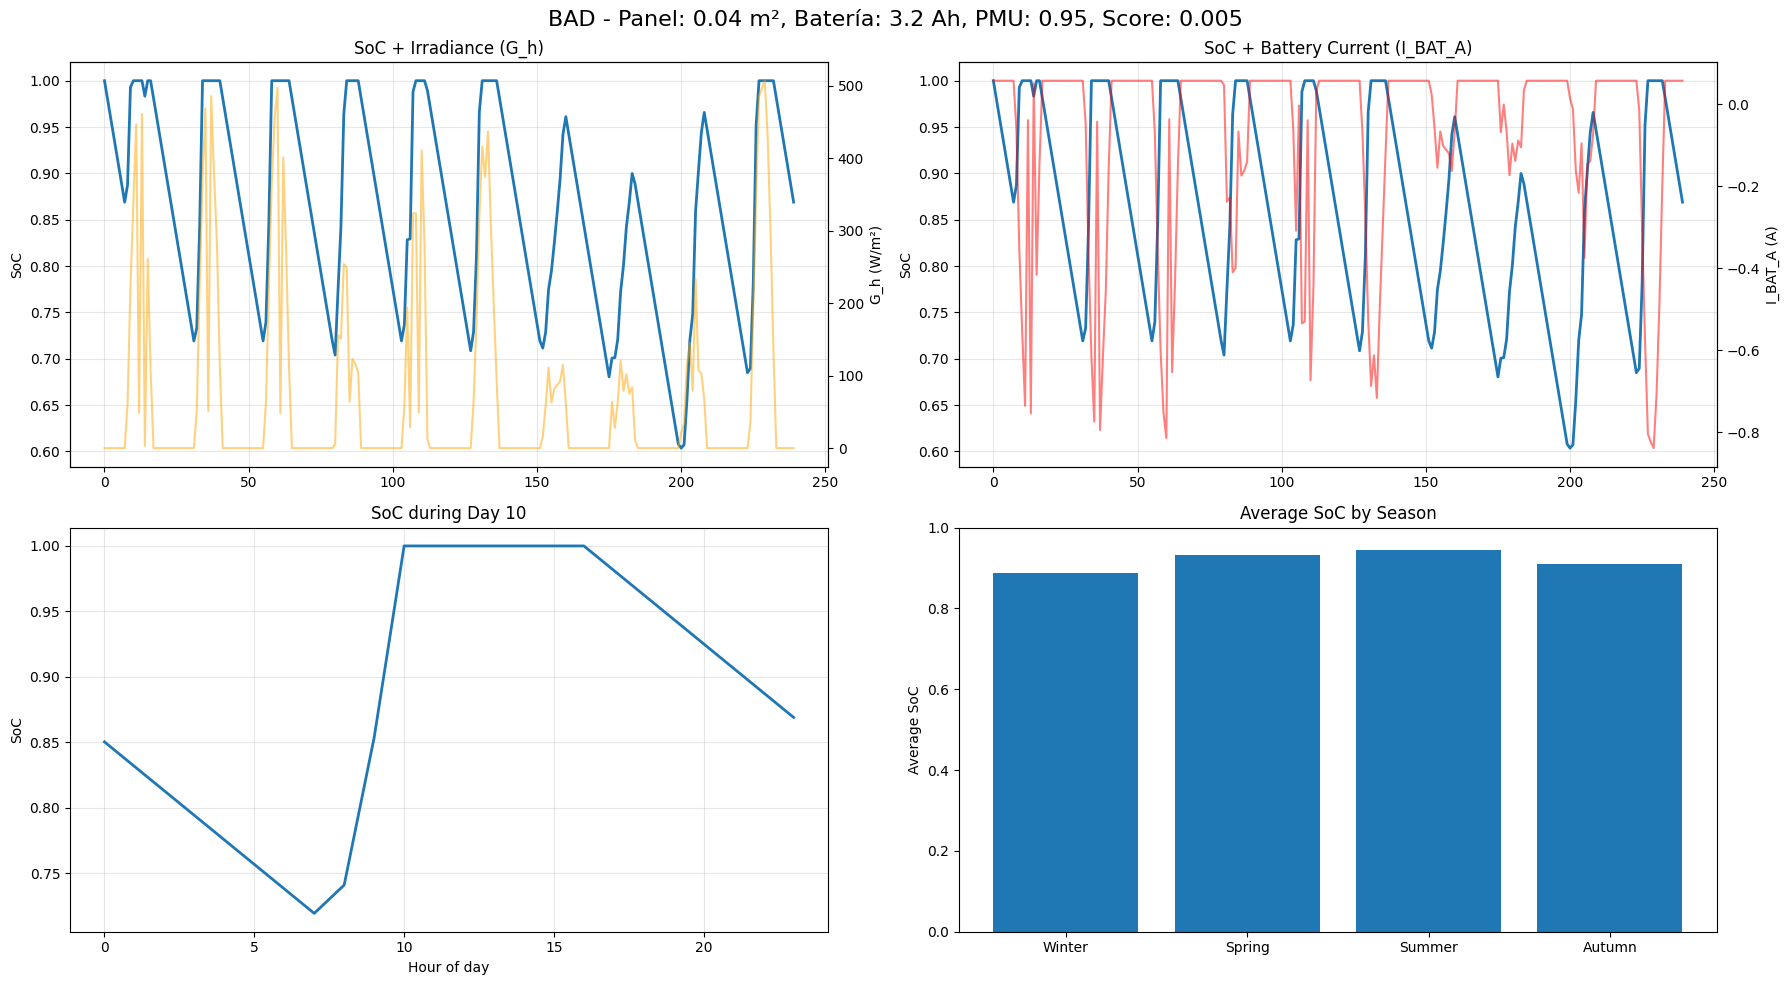

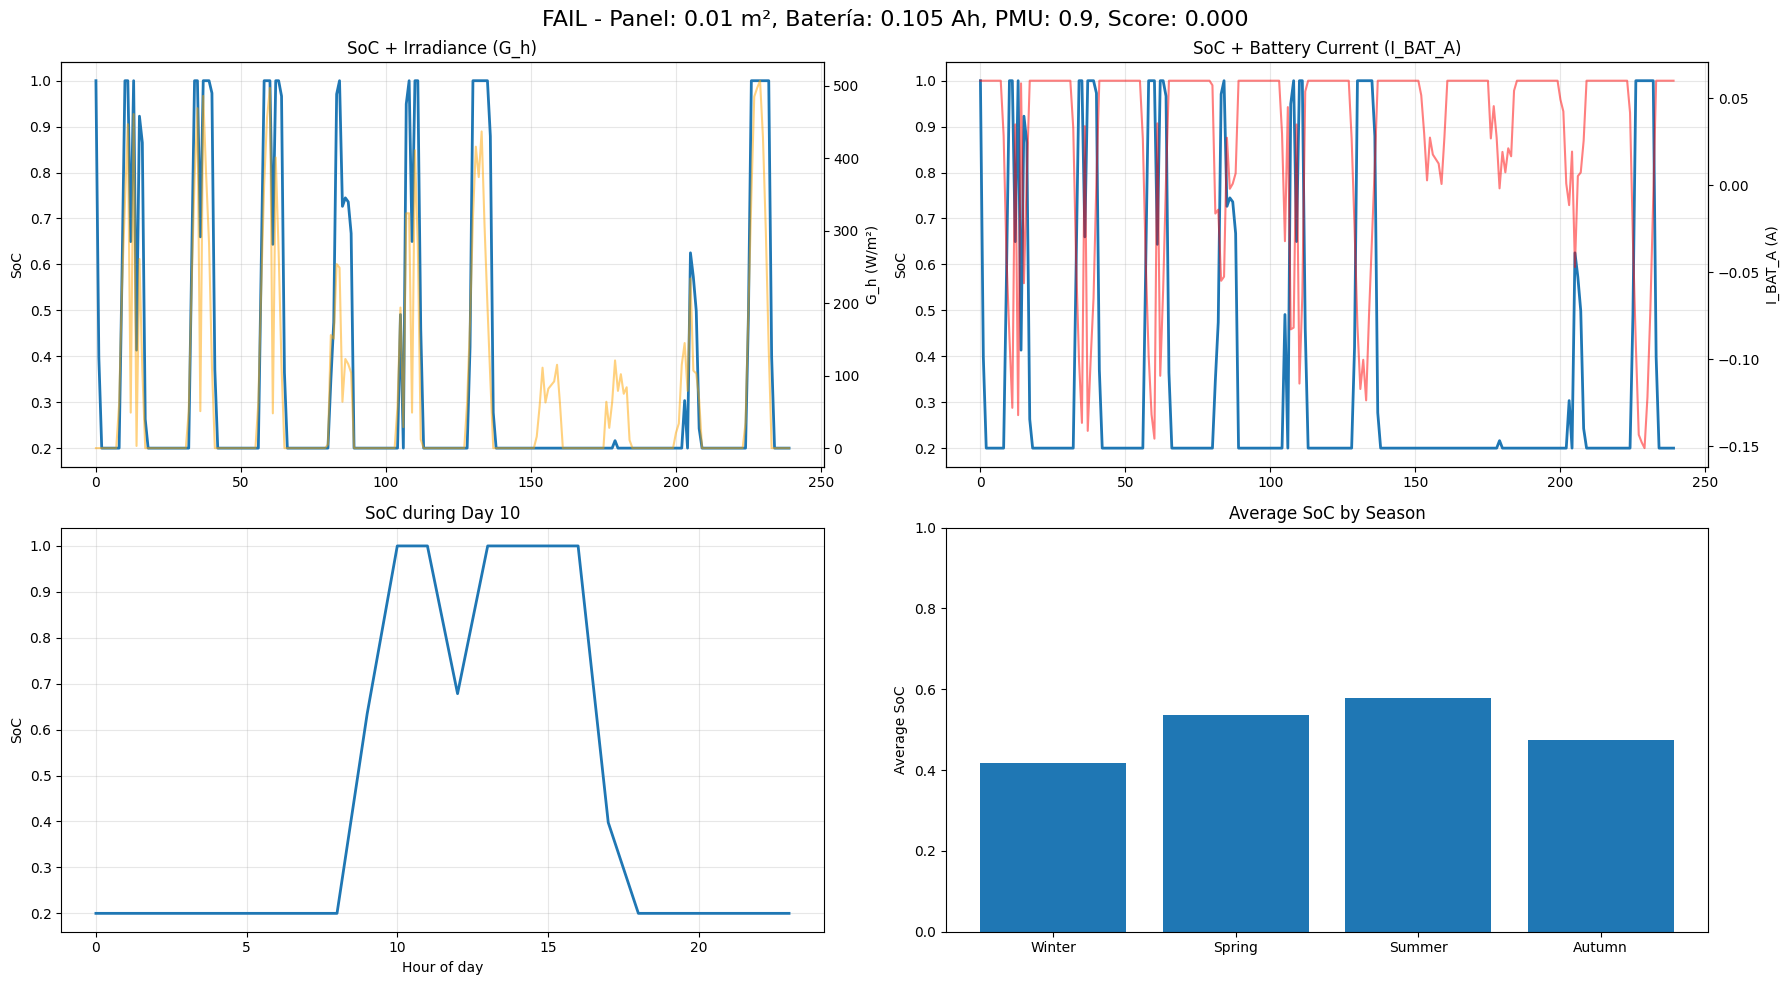

In [22]:
# === BEST SCORE ===
plot_full_soc_analysis(
    title_best,
    df_soc, df_pv,
    cfg_best["panel_area_m2"],
    cfg_best["C_batt_Ah"],
    cfg_best["eta_PMU"],
    hours=240,
    day_index=10
)

# === MID-SCORE (~0.5) ===
plot_full_soc_analysis(
    title_mid,
    df_soc, df_pv,
    cfg_mid["panel_area_m2"],
    cfg_mid["C_batt_Ah"],
    cfg_mid["eta_PMU"],
    hours=240,
    day_index=10
)

# === BAD NON-ZERO SCORE ===
plot_full_soc_analysis(
    title_bad,
    df_soc, df_pv,
    cfg_bad["panel_area_m2"],
    cfg_bad["C_batt_Ah"],
    cfg_bad["eta_PMU"],
    hours=240,
    day_index=10
)

# === FAILURE CASE ===
plot_full_soc_analysis(
    title_fail,
    df_soc, df_pv,
    cfg_fail["panel_area_m2"],
    cfg_fail["C_batt_Ah"],
    cfg_fail["eta_PMU"],
    hours=240,
    day_index=10
)


## Pareto front

In [ ]:
# ── Compute Pareto front ────────────────────────────────────────────────────
objectives = ["C_batt_Ah", "panel_area_m2", "soc_full_fraction"]
criteria =   [-1,          -1,              -1]

front = simulator.pareto_front(
    summary, objectives, criteria)

print(f"{len(front)} configurations on the Pareto front (out of "
      f"{(summary['failure_hours'] == 0).sum()} viable ones)\n")

for i, row in front.iterrows():
    print(f"--- Config #{i} ---")
    print(f"  Panel area  : {row['panel_area_m2']*1e4:.1f} cm²  ({row['panel_area_m2']} m²)")
    print(f"  Battery     : {row['C_batt_Ah']} Ah")
    print(f"  η_PMU       : {row['eta_PMU']}")
    print(f"  SoC full    : {row['soc_full_fraction']*100:.1f}%")
    print(f"  Autonomy    : {row['autonomy_hours']} h")
    print(f"  Failures    : {int(row['failure_hours'])} h")
    print()


4 configurations on the Pareto front (out of 23 viable ones)

--- Config #0 ---
  Panel area  : 400.0 cm²  (0.04 m²)
  Battery     : 1.6 Ah
  η_PMU       : 0.95
  SoC full    : 36.8%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #1 ---
  Panel area  : 310.0 cm²  (0.031 m²)
  Battery     : 2.3 Ah
  η_PMU       : 0.98
  SoC full    : 34.9%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #2 ---
  Panel area  : 310.0 cm²  (0.031 m²)
  Battery     : 2.5 Ah
  η_PMU       : 0.95
  SoC full    : 33.8%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #3 ---
  Panel area  : 250.0 cm²  (0.025 m²)
  Battery     : 3.2 Ah
  η_PMU       : 0.95
  SoC full    : 30.9%
  Autonomy    : 8760.0 h
  Failures    : 0 h



In [24]:
plot_pareto_front(
    summary, front, objectives, color_col="eta_PMU").show()


In [28]:
objectives = ["surplus_Ah", "soc_full_fraction", "soc_mean"]
criteria =   [-1,            -1,                  +1]

front = simulator.pareto_front(
    summary, objectives, criteria)

print(f"{len(front)} configurations on the Pareto front (out of "
      f"{(summary['failure_hours'] == 0).sum()} viable ones)\n")

6 configurations on the Pareto front (out of 23 viable ones)



In [27]:
plot_pareto_front(
    summary, front, objectives, color_col="eta_PMU").show()